# Experiment 7: Principal Component Analysis

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Dimensionality Reduction — PCA on Wine dataset  
**Dataset:** `wine.csv (Wine recognition — 178 samples, 13 chemical features, 3 classes)`  
**Lab Book Reference:** §11 Principal Component Analysis, page 49–52

---

## 🎯 Objective

Implement **Principal Component Analysis** on the Wine dataset. We standardise the 13 chemical features, compute principal components, visualise explained variance, project the data onto 2-D and 3-D for visualisation, and compare classifier performance before and after PCA.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 07-Principal-Component-Analysis/07_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 07-Principal-Component-Analysis/07_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   07-Principal-Component-Analysis/07_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '07-Principal-Component-Analysis'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/07-Principal-Component-Analysis


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/07-Principal-Component-Analysis/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/07-Principal-Component-Analysis/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

In [3]:
data = pd.read_csv('../datasets/wine.csv')
print(f"Shape: {data.shape}")
print("\nColumns:", data.columns.tolist())
display(data.head())

print("\nClass distribution:")
print(data['target'].value_counts().sort_index())


Shape: (178, 14)

Columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


## 3. Check Null Values & Define Features/Target

In [4]:
print("Null values per column:")
print(data.isnull().sum())

X = data.drop('target', axis=1)
y = data['target']
print(f"\nFeatures: {X.shape[1]} columns, {X.shape[0]} samples")
print(f"Classes  : {sorted(y.unique())}")


Null values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Features: 13 columns, 178 samples
Classes  : [np.int64(0), np.int64(1), np.int64(2)]


## 4. Feature Scaling — MANDATORY for PCA

PCA maximises variance; features with larger numerical scales would otherwise dominate.
Standardising to zero mean and unit variance is essential.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Standardised shape: {X_scaled.shape}")
print(f"Mean (per feature) ≈ {np.abs(X_scaled.mean()).mean():.2e}")
print(f"Std  (per feature) ≈ {X_scaled.std().mean():.4f}")


Standardised shape: (178, 13)
Mean (per feature) ≈ 1.23e-16
Std  (per feature) ≈ 1.0000


## 5. Apply PCA (all components)

In [6]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X.shape[1]}")
print(f"PCA output shape   : {X_pca.shape}")
print(f"\nExplained variance ratio (per PC):")
for i, v in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i:2d}: {v:.4f}  ({v*100:.2f}%)")


Original dimensions: 13
PCA output shape   : (178, 13)

Explained variance ratio (per PC):
  PC 1: 0.3620  (36.20%)
  PC 2: 0.1921  (19.21%)
  PC 3: 0.1112  (11.12%)
  PC 4: 0.0707  (7.07%)
  PC 5: 0.0656  (6.56%)
  PC 6: 0.0494  (4.94%)
  PC 7: 0.0424  (4.24%)
  PC 8: 0.0268  (2.68%)
  PC 9: 0.0222  (2.22%)
  PC10: 0.0193  (1.93%)
  PC11: 0.0174  (1.74%)
  PC12: 0.0130  (1.30%)
  PC13: 0.0080  (0.80%)


## 6. Cumulative Explained Variance

Components to retain ≥ 90 % variance: 8
Components to retain ≥ 95 % variance: 10


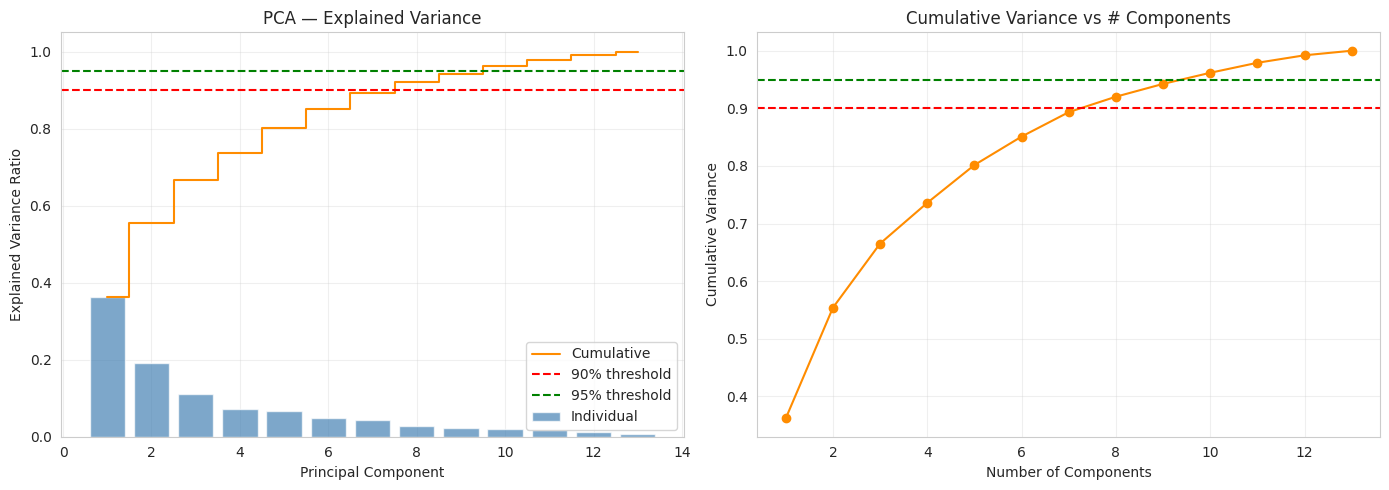

In [7]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components to retain ≥ 90 % variance: {n_components_90}")
print(f"Components to retain ≥ 95 % variance: {n_components_95}")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_, color='steelblue', alpha=0.7, label='Individual')
plt.step(range(1, len(cum_var)+1), cum_var, where='mid',
         color='darkorange', label='Cumulative')
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.axhline(0.95, color='green', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cum_var)+1), cum_var, 'o-', color='darkorange')
plt.axhline(0.90, color='red', linestyle='--')
plt.axhline(0.95, color='green', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance vs # Components')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. 2-D Projection (PC1 vs PC2)

Reduced shape: (178, 2)
Variance retained: 55.41%


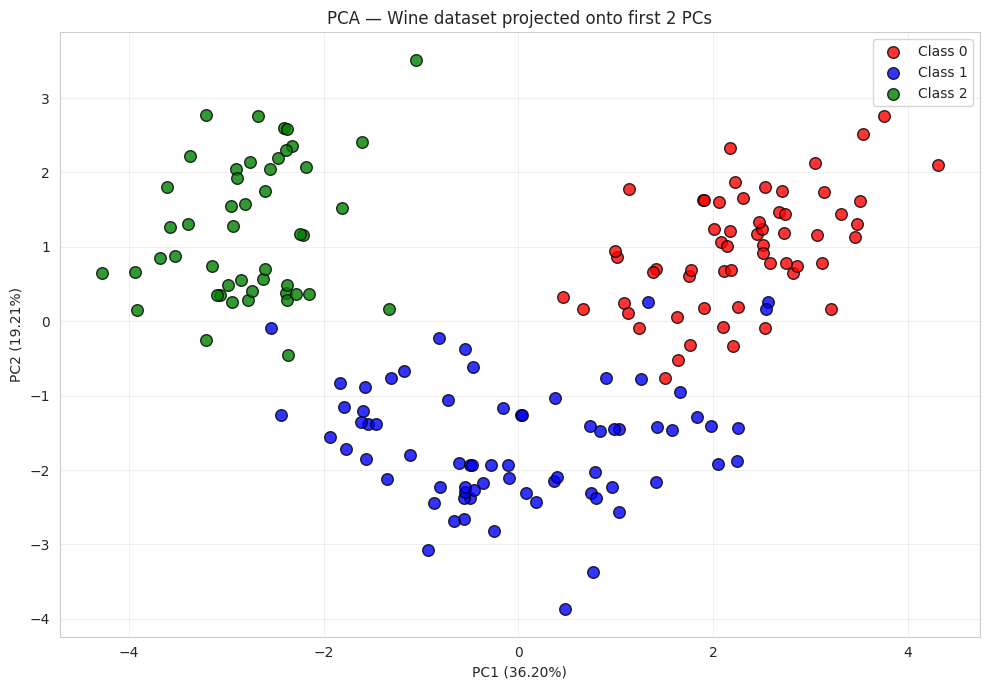

In [8]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
print(f"Reduced shape: {X_pca_2.shape}")
print(f"Variance retained: {pca_2.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green']
for label, color in zip(sorted(y.unique()), colors):
    plt.scatter(X_pca_2[y == label, 0], X_pca_2[y == label, 1],
                c=color, label=f'Class {label}', s=70, edgecolor='k', alpha=0.8)
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA — Wine dataset projected onto first 2 PCs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. 3-D Projection (PC1, PC2, PC3)

Variance retained by 3 PCs: 66.53%


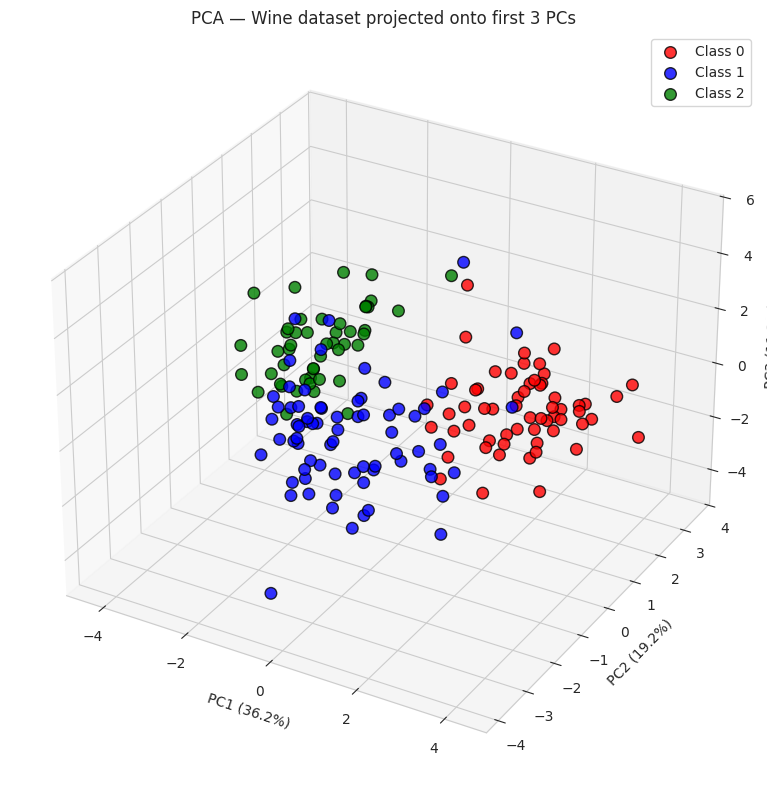

In [9]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)
print(f"Variance retained by 3 PCs: {pca_3.explained_variance_ratio_.sum()*100:.2f}%")

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
for label, color in zip(sorted(y.unique()), colors):
    ax.scatter(X_pca_3[y == label, 0], X_pca_3[y == label, 1], X_pca_3[y == label, 2],
               c=color, label=f'Class {label}', s=70, edgecolor='k', alpha=0.8)
ax.set_xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA — Wine dataset projected onto first 3 PCs')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Feature Loadings (which features drive each PC)

,PC1,PC2,PC3
flavanoids,0.4229,-0.0034,0.1507
total_phenols,0.3947,0.0650,0.1462
od280/od315_of_diluted_wines,0.3762,-0.1645,0.1660
proanthocyanins,0.3134,0.0393,0.1495
hue,0.2967,-0.2792,0.0852


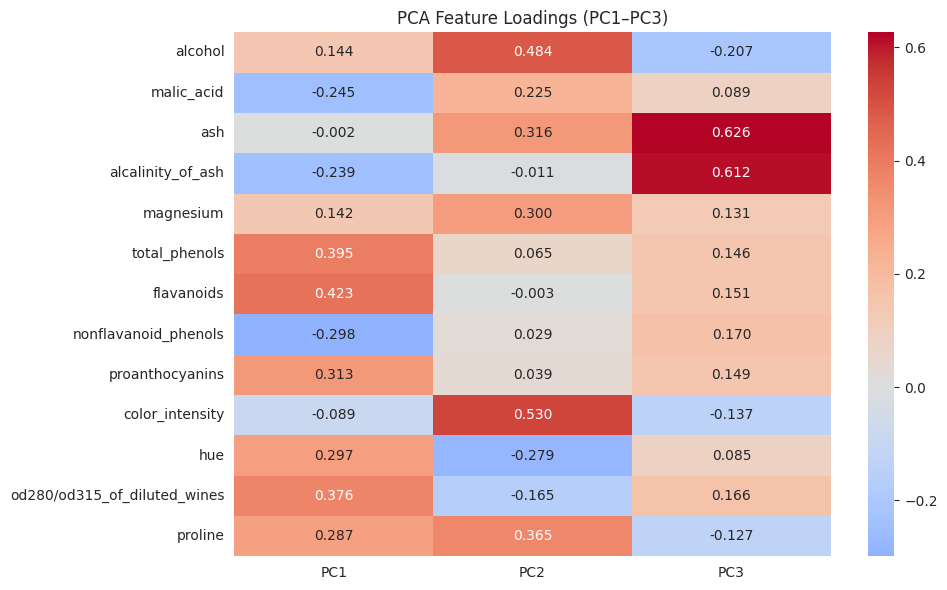

In [10]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns,
).round(4)
display(loadings.sort_values('PC1', ascending=False).head(5))

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.3f')
plt.title('PCA Feature Loadings (PC1–PC3)')
plt.tight_layout()
plt.show()


## 10. Compare Model Performance: Original vs PCA-Reduced

Train a Logistic Regression classifier on:
- (a) the full 13-feature standardised dataset,
- (b) the PCA-reduced dataset (2 components).

PCA reduces dimensionality at the cost of (usually small) accuracy loss.


In [11]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# (a) Full features
clf_full = LogisticRegression(max_iter=5000, random_state=42)
clf_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, clf_full.predict(X_test))

# (b) PCA-2 features
X_train_pca = pca_2.transform(X_train) if False else PCA(n_components=2).fit_transform(X_train)
# Re-fit PCA on training only to avoid leakage
pca_pipe = PCA(n_components=2)
X_train_pca = pca_pipe.fit_transform(X_train)
X_test_pca  = pca_pipe.transform(X_test)
clf_pca = LogisticRegression(max_iter=5000, random_state=42)
clf_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, clf_pca.predict(X_test_pca))

print(f"Accuracy with 13 original features : {acc_full:.4f}")
print(f"Accuracy with 2 PCA components     : {acc_pca:.4f}")
print(f"\nDimensionality reduction: 13 → 2 (≈{100*(1-2/13):.0f}% fewer features)")
print(f"Accuracy trade-off      : {(acc_full - acc_pca)*100:+.2f} %")


Accuracy with 13 original features : 0.9722
Accuracy with 2 PCA components     : 0.9167

Dimensionality reduction: 13 → 2 (≈85% fewer features)
Accuracy trade-off      : +5.56 %


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Maggie is a real-estate agent puzzled about why some properties have not been sold for more than 6 months. Use PCA to identify the **principal components** of property features that explain slow sales.
2. For the dataset below, identify which variable is the principal component. (Climate, Housing, Health, Crime, Transportation, Education, Arts, Recreation, Economy — see Lab Book page 52.)
3. Apply PCA to the **MNIST digits** dataset (`sklearn.datasets.load_digits`) and visualise the 2-D projection. How many components retain 95 % of the variance?


---

## 📚 Key Takeaways

- **PCA** is an unsupervised linear dimensionality-reduction technique.
- **Steps:** standardise → covariance matrix → eigenvectors/eigenvalues → sort → project.
- **Explained variance ratio** tells you how much information each PC retains.
- **Use cases:** visualisation (2-D / 3-D), noise filtering, feature extraction, accelerating downstream classifiers.
- **Caveat:** PCA is **linear** — non-linear structure may require t-SNE, UMAP, or Kernel PCA.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
